# Classic Monte Carlo Simulations

## 1. Estimating value of Pi

Imagine a unit circle (radius = 1) inside a square.

1. Square dimensions: [-1,1] × [-1,1]
2. Square area = 4
3. Circle radius = 1
4. Circle area = π

If we throw random points uniformly into the square,

Probability(point inside circle) = Circle Area / Square Area = π / 4

Therefore,
π ≈ 4 * points inside / total points

This is an example of using Monte Carlo simulation to estimate an unknown quantity by sampling random outcomes and averaging the results.

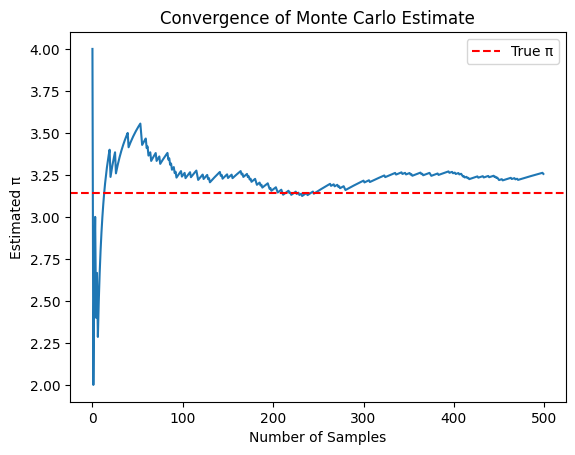

In [6]:
import random
import matplotlib.pyplot as plt

N = 500

inside = 0
estimates = []

for i in range(1, N + 1):

    x = random.uniform(-1,1)
    y = random.uniform(-1,1)

    if x*x + y*y <= 1:
        inside += 1

    estimates.append(4 * inside / i)

plt.plot(estimates)
plt.axhline(3.14159265, color='red', linestyle='--', label='True π')

plt.xlabel("Number of Samples")
plt.ylabel("Estimated π")
plt.title("Convergence of Monte Carlo Estimate")
plt.legend()

plt.show()

### Printing Results for Different Sample Sizes

In [12]:
import random

sample_sizes = [50, 100, 500, 1000, 1500, 10000, 15000, 100000,150000]

for N in sample_sizes:

    inside = 0

    for _ in range(N):
        x = random.uniform(-1,1)
        y = random.uniform(-1,1)

        if x*x + y*y <= 1:
            inside += 1

    pi = 4 * inside / N

    print(f"{N:7d} samples : {pi:.6f}")

     50 samples : 3.200000
    100 samples : 3.120000
    500 samples : 3.168000
   1000 samples : 3.068000
   1500 samples : 3.101333
  10000 samples : 3.133200
  15000 samples : 3.132533
 100000 samples : 3.142120
 150000 samples : 3.146960


## 2. 2D Walk

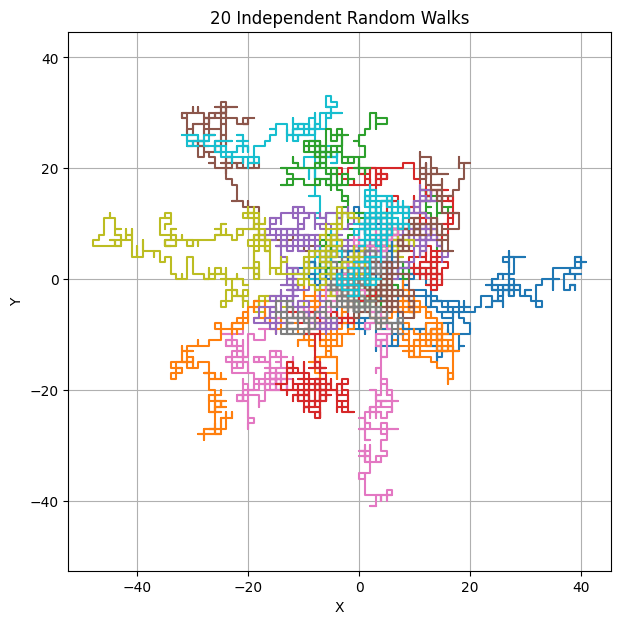

In [14]:
import random
import matplotlib.pyplot as plt

steps = 500
walkers = 20

plt.figure(figsize=(7,7))

for _ in range(walkers):

    x = y = 0
    xs = [x]
    ys = [y]

    for _ in range(steps):

        direction = random.randint(0,3)

        if direction == 0:
            x += 1
        elif direction == 1:
            x -= 1
        elif direction == 2:
            y += 1
        else:
            y -= 1

        xs.append(x)
        ys.append(y)

    plt.plot(xs, ys)

plt.title(f"{walkers} Independent Random Walks")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid(True)

plt.show()

### The same stochastic process can diverge dramatically despite following identical rules.

### Run many simulations to calculate the probability that the runner would return to origin and the expected distance

In [22]:
import random
import math

# Monte Carlo parameters
num_walks = 1000      # Number of simulations
num_steps = 100      # Steps per walk

returns = 0
total_distance = 0

print(f"{'Walk':<6}{'Returned?':<12}{'Final Position':<18}{'Distance'}")
print("-" * 50)

for walk in range(1, num_walks + 1):

    x, y = 0, 0

    # Perform one random walk
    for _ in range(num_steps):

        direction = random.randint(0, 3)

        if direction == 0:
            y += 1
        elif direction == 1:
            y -= 1
        elif direction == 2:
            x += 1
        else:
            x -= 1

    # Compute statistics for this walk
    distance = math.sqrt(x**2 + y**2)
    returned = (x == 0 and y == 0)

    if returned:
        returns += 1

    total_distance += distance

    print(f"{walk:<6}{str(returned):<12}{str((x, y)):<18}{distance:.2f}")

# Monte Carlo estimates
return_probability = returns / num_walks
expected_distance = total_distance / num_walks

Walk  Returned?   Final Position    Distance
--------------------------------------------------
1     False       (-8, 2)           8.25
2     False       (-7, 9)           11.40
3     False       (-8, 10)          12.81
4     False       (-4, -4)          5.66
5     False       (2, -8)           8.25
6     False       (0, -8)           8.00
7     False       (-6, -2)          6.32
8     False       (-3, 1)           3.16
9     False       (-3, 5)           5.83
10    False       (-6, 14)          15.23
11    True        (0, 0)            0.00
12    False       (4, 0)            4.00
13    False       (-4, -4)          5.66
14    False       (6, 10)           11.66
15    False       (1, -13)          13.04
16    False       (2, 20)           20.10
17    False       (3, -5)           5.83
18    False       (-10, -2)         10.20
19    False       (-2, 20)          20.10
20    False       (-11, -5)         12.08
21    False       (0, -6)           6.00
22    False       (12, -8)        

In [23]:
print("\n" + "=" * 50)
print(f"Total simulations           : {num_walks}")
print(f"Steps per simulation        : {num_steps}")
print(f"Returned to origin          : {returns}")
print(f"Estimated Return Probability: {return_probability:.4f}")
print(f"Expected Distance           : {expected_distance:.2f}")
print("\n" + "=" * 50)


Total simulations           : 1000
Steps per simulation        : 100
Returned to origin          : 9
Estimated Return Probability: 0.0090
Expected Distance           : 8.83

